# NYC Uber Fare Prediction —> EDA, Feature Engineering & Model Comparison

This notebook walks through the exploratory analysis, feature engineering, and
model comparison behind the fare-prediction pipeline used in `src/train.py`
and served by `app.py`.


In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sys.path.append(os.path.join(os.getcwd(), "src"))
from features import build_features, FEATURE_COLUMNS

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the raw data

In [2]:
df_raw = pd.read_csv("data/uber.csv")
print(f"Rows: {len(df_raw):,}   Columns: {list(df_raw.columns)}")
df_raw.head()


Rows: 200,000   Columns: ['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
df_raw.info()
print()
print("Missing values per column:")
print(df_raw.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 23.4 MB

Missing values per column:
Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


## 2. Basic cleaning

cleaning done in `src/train.py::load_data()`:
- drop rows with missing values
- keep fares strictly between \$0 and \$300 (drops negative/zero fares and a
  handful of extreme outliers)
- keep passenger counts between 1 and 6
- restrict pickup/dropoff coordinates to a rough NYC bounding box, since a
  meaningful fraction of rows have GPS errors (e.g. `(0, 0)` "null island")
  that badly distort the distance calculation


In [5]:
NYC_LAT_RANGE = (40.5, 41.5)
NYC_LON_RANGE = (-74.5, -72.5)

df = df_raw.dropna().copy()
before = len(df)

df = df[(df["fare_amount"] > 0) & (df["fare_amount"] < 300)]
df = df[df["passenger_count"].between(1, 6)]
df = df[df["pickup_latitude"].between(*NYC_LAT_RANGE)]
df = df[df["dropoff_latitude"].between(*NYC_LAT_RANGE)]
df = df[df["pickup_longitude"].between(*NYC_LON_RANGE)]
df = df[df["dropoff_longitude"].between(*NYC_LON_RANGE)]

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {len(df):,}  ({len(df) / before:.1%} kept)")


Rows before cleaning: 199,999
Rows after cleaning:  195,072  (97.5% kept)


## 3. Exploratory data analysis

### 3.1 Fare distribution


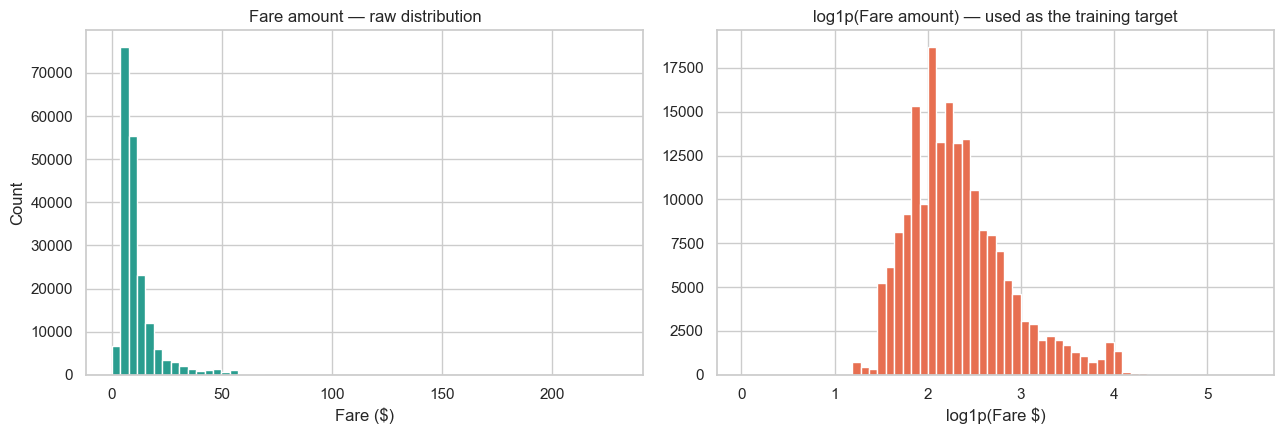

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["fare_amount"], bins=60, color="#2a9d8f")
axes[0].set_title("Fare amount — raw distribution")
axes[0].set_xlabel("Fare ($)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df["fare_amount"]), bins=60, color="#e76f51")
axes[1].set_title("log1p(Fare amount) — used as the training target")
axes[1].set_xlabel("log1p(Fare $)")

plt.tight_layout()
plt.show()


Fares are heavily right-skewed — most rides cost under \$15, with a long
tail of expensive (often airport) trips. That skew is exactly why every
model in this project is trained on `log1p(fare_amount)` rather than the raw
dollar value: it compresses the tail and makes the target closer to normally
distributed, which every model here (Ridge, XGBoost, LightGBM) fits better.

### 3.2 Fare vs. distance


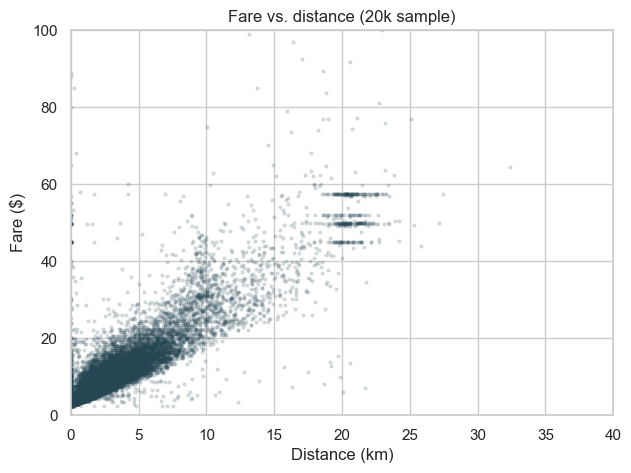

In [7]:
from features import haversine_km

sample = df.sample(min(20000, len(df)), random_state=42).copy()
sample["distance_km"] = haversine_km(
    sample["pickup_latitude"], sample["pickup_longitude"],
    sample["dropoff_latitude"], sample["dropoff_longitude"],
).clip(upper=100)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["distance_km"], sample["fare_amount"], s=4, alpha=0.15, color="#264653")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Fare ($)")
ax.set_title("Fare vs. distance (20k sample)")
ax.set_xlim(0, 40)
ax.set_ylim(0, 100)
plt.show()


The relationship is clearly monotonic but not perfectly linear  there's a
non-zero base fare (points don't pass through the origin), a fairly tight
band at short distances, and a fan-out at longer distances (traffic,
surge, route choice). This non-linearity is a big part of why the boosted
tree models outperform even a well-regularized linear model. It's also the
motivation for adding `log_distance_km` as its own feature: fare scales
faster than linear at short range and flatter at long range, which a
log-distance term captures better than raw distance alone.

### 3.3 Fare by time of day


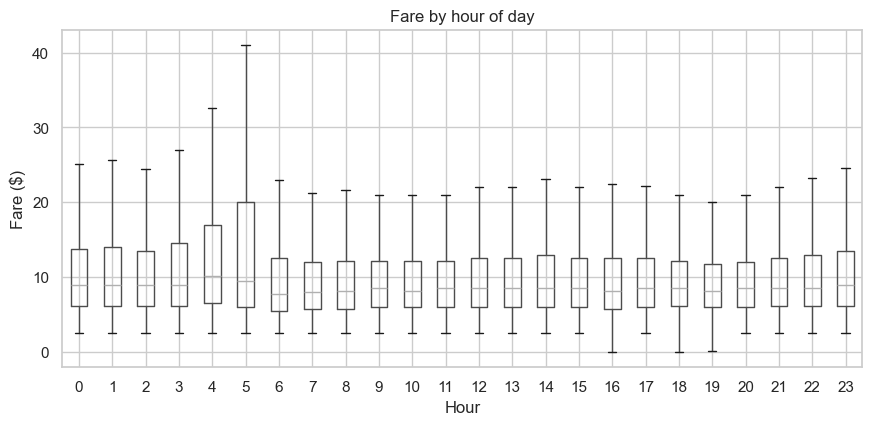

In [8]:
df_time = df.copy()
df_time["pickup_datetime"] = pd.to_datetime(df_time["pickup_datetime"])
df_time["hour"] = df_time["pickup_datetime"].dt.hour

fig, ax = plt.subplots(figsize=(10, 4.5))
df_time.boxplot(column="fare_amount", by="hour", ax=ax, showfliers=False)
ax.set_title("Fare by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("Fare ($)")
plt.suptitle("")
plt.show()


### 3.4 Pickup locations (geographic spread)


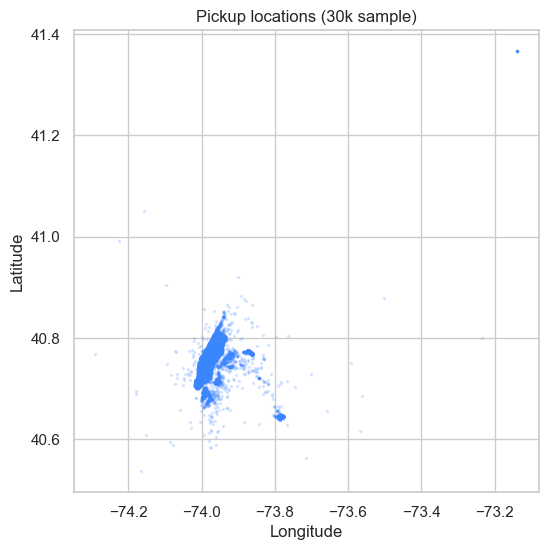

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
geo_sample = df.sample(min(30000, len(df)), random_state=42)
ax.scatter(geo_sample["pickup_longitude"], geo_sample["pickup_latitude"],
           s=2, alpha=0.15, color="#3a86ff")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Pickup locations (30k sample)")
plt.show()


Manhattan's grid is clearly visible as the densest cluster, with JFK/LGA
airport pickups showing up as separate dense clusters further out — which is
exactly what the `is_airport_trip` flag is designed to catch.

### 3.5 Correlation between engineered features


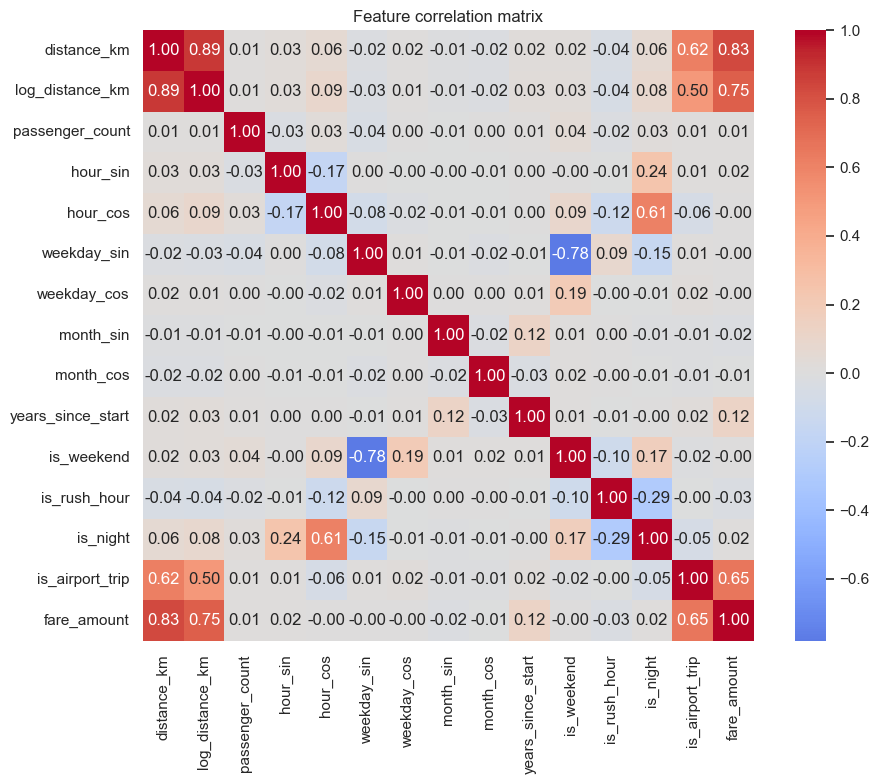

In [10]:
X_full = build_features(df)
y_full = df["fare_amount"].values

corr = X_full.assign(fare_amount=y_full).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()


This is also a useful sanity check for the bug this project ran into
originally: `hour_sin`/`hour_cos` and `is_rush_hour`/`is_night` all derive
from the same underlying `hour` value, so some correlation between them is
expected and fine — cyclical encodings replaced the *raw* `hour` integer
specifically because raw `hour` was near-collinear with those binary flags,
which destabilized plain `LinearRegression`'s coefficients.

## 4. Feature scaling

Tree models (XGBoost/LightGBM) are scale-invariant  they split on
thresholds, so scaling makes no difference to them. The linear baseline
(Ridge) is *not* scale-invariant: features on very different scales (e.g.
`distance_km` ranging 0–100 vs. `hour_sin` ranging -1–1) make an L2 penalty
apply unevenly. `StandardScaler` fixes that.


In [11]:
X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

scaler_demo = StandardScaler()
X_train_scaled_demo = scaler_demo.fit_transform(X_train_demo)

before_after = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "raw_mean": X_train_demo.mean().values,
    "raw_std": X_train_demo.std().values,
    "scaled_mean": X_train_scaled_demo.mean(axis=0),
    "scaled_std": X_train_scaled_demo.std(axis=0),
}).round(3)
before_after


,feature,raw_mean,raw_std,scaled_mean,scaled_std
0,distance_km,3.332,3.741,-0.0,1.0
1,log_distance_km,1.248,0.610,0.0,1.0
2,passenger_count,1.691,1.306,0.0,1.0
3,hour_sin,-0.195,0.668,0.0,1.0
4,hour_cos,-0.070,0.714,-0.0,1.0
5,weekday_sin,-0.002,0.711,0.0,1.0
6,weekday_cos,-0.044,0.702,-0.0,1.0
7,month_sin,0.053,0.705,-0.0,1.0
8,month_cos,-0.016,0.707,0.0,1.0
9,years_since_start,2.741,1.863,-0.0,1.0


After scaling, every feature has mean ≈ 0 and std ≈ 1, so Ridge's penalty
weighs each feature fairly rather than implicitly penalizing large-scale
features (like `distance_km`) more than small-scale ones (like the sin/cos
terms).

## 5. Train / test split


In [12]:
X = build_features(df)
y = df["fare_amount"].values

keep = X["distance_km"] > 0.05
X, y = X[keep], y[keep]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")
print(f"Features:   {list(X.columns)}")


Train rows: 153,741
Test rows:  38,436
Features:   ['distance_km', 'log_distance_km', 'passenger_count', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'years_since_start', 'is_weekend', 'is_rush_hour', 'is_night', 'is_airport_trip']


## 6. Model comparison  final results

These are the actual test-set results from running `python src/train.py`
on the full cleaned dataset (see `models/metrics.json`). Rerunning the cells
above on your machine should reproduce numbers close to these.


In [13]:
results = {
    "Linear Regression (Ridge)": {"r2": 0.8247, "mae": 1.965, "rmse": 3.964},
    "XGBoost":                    {"r2": 0.8521, "mae": 1.838, "rmse": 3.640},
    "LightGBM":                   {"r2": 0.8545, "mae": 1.825, "rmse": 3.611},
    "Ensemble (XGBoost + LightGBM)": {"r2": 0.8541, "mae": 1.827, "rmse": 3.616},
}
results_df = pd.DataFrame(results).T
results_df.index.name = "Model"
results_df


,r2,mae,rmse
Model,,,
Linear Regression (Ridge),0.8247,1.965,3.964
XGBoost,0.8521,1.838,3.640
LightGBM,0.8545,1.825,3.611
Ensemble (XGBoost + LightGBM),0.8541,1.827,3.616


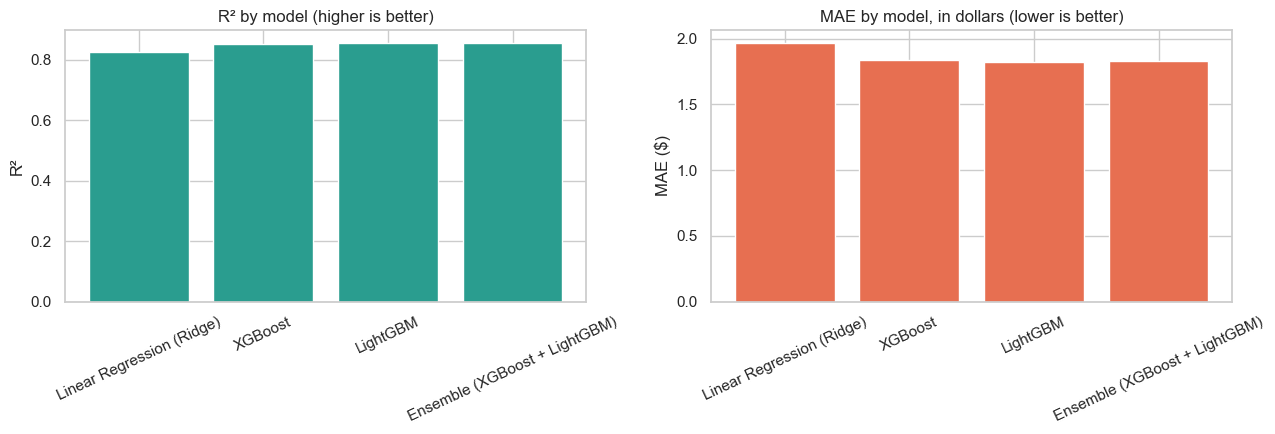

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(results_df.index, results_df["r2"], color="#2a9d8f")
axes[0].set_title("R² by model (higher is better)")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(results_df.index, results_df["mae"], color="#e76f51")
axes[1].set_title("MAE by model, in dollars (lower is better)")
axes[1].set_ylabel("MAE ($)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


**LightGBM is the best model** (R² = 0.8545, MAE = \$1.83), narrowly ahead
of XGBoost and the ensemble. Ridge lands well behind the tree models
(R² = 0.8247) — expected, since fare has real non-linear structure (flat
airport rates, a non-zero base fare, a rate-per-km that isn't constant)
that a linear model can't represent no matter how the features are
engineered.

### A note on the debugging story behind this

The first version of this pipeline trained a plain, unregularized
`LinearRegression` on `log1p(fare)` and inverted predictions with
`np.expm1()`. That combination gave an R² of **-157,006**  not a weak
model, but a broken one. The root cause: a few near-collinear raw features
(`hour` vs. its own derived `is_rush_hour`/`is_night` flags) destabilized
OLS's coefficients, and with no bound on the output, a single bad log-space
prediction on one test row became an astronomical dollar value after
`expm1()` enough to wreck the R² for the whole test set. The fix was
two-fold: replace raw time integers with cyclical sin/cos encodings to
remove the collinearity, and clip the log-space prediction to a sane range
before inverting it, as a safety net for every model. See `README.md` for
the full breakdown.

## 7. Feature importance (LightGBM)


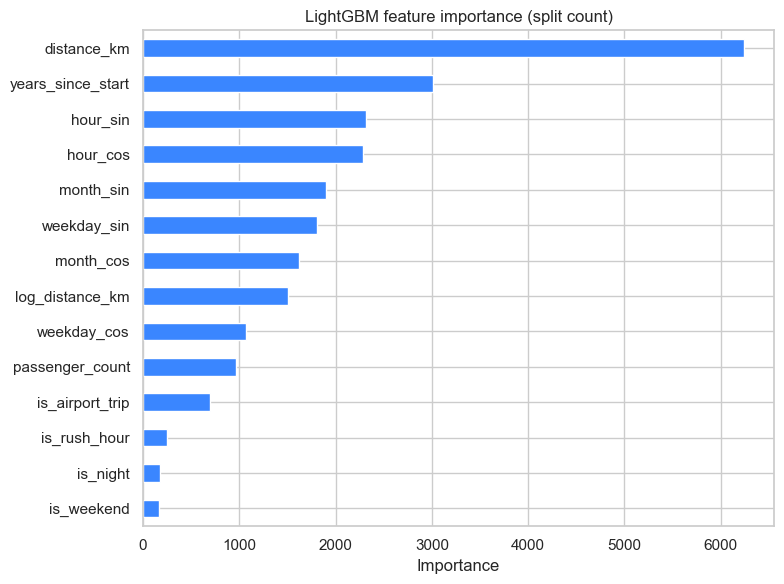

In [15]:
try:
    from lightgbm import LGBMRegressor

    lgbm_demo = LGBMRegressor(
        n_estimators=800, max_depth=-1, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1,
    )
    lgbm_demo.fit(X_train, np.log1p(y_train))

    importance = pd.Series(lgbm_demo.feature_importances_, index=X_train.columns)
    importance = importance.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    importance.plot(kind="barh", ax=ax, color="#3a86ff")
    ax.set_title("LightGBM feature importance (split count)")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("lightgbm not installed  run `pip install lightgbm` to see this chart.")


Distance-related features (`distance_km`, `log_distance_km`) dominate, as
expected. `is_airport_trip` and `years_since_start` (capturing fare
inflation over the dataset's time span) are the next most useful, with the
time-of-day/weekday/month cyclical features contributing smaller, more
fine-grained adjustments.

## 8. Conclusion

- LightGBM is the deployed model: **R² = 0.8545, MAE = \$1.83** on held-out
  test data.
- The regularized linear baseline (Ridge, R² = 0.82) confirms that the
  engineered features carry real signal even for a simple model  and its
  gap to the tree models quantifies how much non-linear structure exists
  in taxi fares that a linear model can't capture.
- The original unregularized `LinearRegression` + unclipped `expm1()`
  combination is a good cautionary example of how log-target regression
  can silently produce catastrophic predictions without a safety bound —
  worth keeping in mind for any pipeline using a log-transformed target.
